# 采样加速：让扩散模型快起来

> **难度：** 中级 | **时间：** 约 50 分钟

DDPM 能生成出色的样本，但每张图需要 1000 次顺序的神经网络前向传播——对于生产环境来说太慢了。本 notebook 将带你了解四个关键突破，它们将采样步数从 1000 步减少到最少 1 步：DDIM、DPM-Solver、渐进蒸馏和一致性模型。

**前置知识：** [00-ddpm-foundations.ipynb](00-ddpm-foundations.ipynb)。你需要理解前向过程、噪声调度和基本的 DDPM 逆向采样循环。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.diffusion import (
    linear_beta_schedule, cosine_beta_schedule, compute_alpha_bars, compute_snr,
    q_sample, SimpleDenoiser, make_swiss_roll,
    train_diffusion_2d, ddpm_sample_loop, ddim_sample_loop,
)
from mp_tutorial.diffusion_viz import draw_denoising_trajectory, draw_training_curves
from mp_tutorial.formatting import info_box
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Setup complete.")

Setup complete.


---
## 1. 采样速度问题

在 [notebook 00](00-ddpm-foundations.ipynb) 中我们看到，DDPM 通过迭代去噪来生成数据，从纯高斯噪声出发，逆向遍历 T=1000 个时间步。每个时间步都需要一次完整的神经网络前向传播。

这在实践中有多糟糕？

In [2]:
# Back-of-the-envelope: wall-clock cost of DDPM at different resolutions
print("Approximate DDPM sampling time (T=1000, single image):")
print(f"{'Resolution':<16s} {'ms/pass':<10s} {'Total':<12s} {'Images/min':<12s}")
print("-" * 50)
for res, ms in [("256x256", 20), ("512x512", 50), ("1024x1024", 150)]:
    total_s = 1000 * ms / 1000
    per_min = 60 / total_s
    print(f"{res:<16s} {ms:<10d} {total_s:<12.1f} {per_min:<12.1f}")

print("\nCompare: a GAN generates one image in a single forward pass (~20 ms).")
print("DDPM is 1000x slower.  We need to close that gap.")

Approximate DDPM sampling time (T=1000, single image):
Resolution       ms/pass    Total        Images/min  
--------------------------------------------------
256x256          20         20.0         3.0         
512x512          50         50.0         1.2         
1024x1024        150        150.0        0.4         

Compare: a GAN generates one image in a single forward pass (~20 ms).
DDPM is 1000x slower.  We need to close that gap.


In [3]:
info_box(
    "前向过程用 1000 步逐渐破坏数据，但我们<b>不需要</b>逆转每一步。"
    "所有快速采样器背后的核心洞察：我们可以<i>跳过</i>时间步——"
    "直接从 t=1000 跳到 t=950，再跳到 t=900，以此类推。"
    "问题在于如何在不破坏生成质量的前提下迈出这些更大的步子。",
    title="核心洞察"
)

---
## 2. DDIM：用更少步骤的确定性采样

**DDIM**（Denoising Diffusion Implicit Models，Song et al. 2020）是快速扩散采样的第一个重大突破。

### 为什么 DDPM 不能轻松跳步

DDPM 的逆向过程是**马尔可夫的**：每一步 $x_t \to x_{t-1}$ 只依赖于 $x_t$，
而且每一步都会添加新的随机噪声。如果你试图跳步，累积的噪声分布就不对了，
生成质量会下降。

### DDIM 的洞察：非马尔可夫公式

DDIM 指出，*同一个*前向过程可以用一族**非马尔可夫**的逆向过程来描述。
这个族中有一个特殊成员是完全**确定性**的（每步不添加随机噪声）。
因为它是确定性的，我们可以直接从 $t$ 跳到任意更早的时间步 $t - k$。

### DDIM 更新公式

给定模型的噪声预测 $\epsilon_\theta(x_t, t)$，首先估计干净数据：

$$\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar\alpha_t}\;\epsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}$$

然后跳到时间步 $t - k$：

$$x_{t-k} = \sqrt{\bar\alpha_{t-k}}\;\hat{x}_0 \;+\; \sqrt{1 - \bar\alpha_{t-k}}\;\epsilon_\theta(x_t, t)$$

### eta（$\eta$）参数

DDIM 引入了参数 $\eta \in [0, 1]$ 来控制随机性：
- $\eta = 0$：完全确定性（最常用——支持插值和反演）
- $\eta = 1$：退化为原始 DDPM 的随机采样器

中间值提供平滑的权衡。实践中几乎总是使用 $\eta = 0$。

Training a diffusion model on Swiss roll (T=200, 300 epochs)...


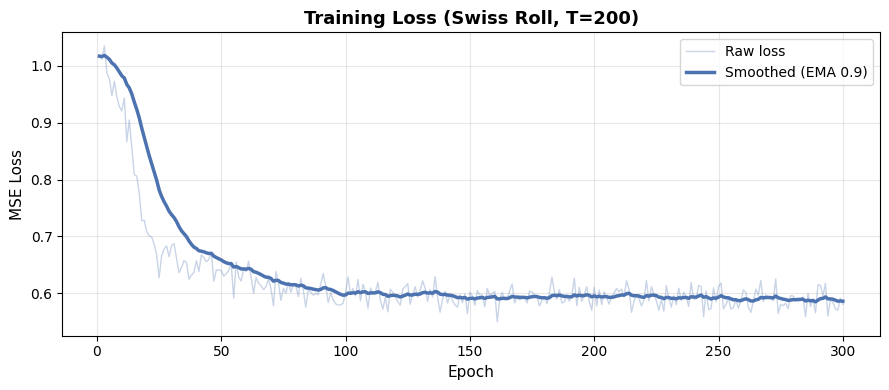

Final loss: 0.580767


In [4]:
# --- Train a model on Swiss roll data (T=200, trains in seconds on CPU) ---
T = 200
print(f"Training a diffusion model on Swiss roll (T={T}, 300 epochs)...")
model, losses = train_diffusion_2d(n_points=2000, T=T, epochs=300, lr=1e-3)

betas = linear_beta_schedule(T)
alpha_bars = compute_alpha_bars(betas)

fig, ax = draw_training_curves(losses, title="Training Loss (Swiss Roll, T=200)")
plt.show()
print(f"Final loss: {losses[-1]:.6f}")

In [5]:
# --- Sample with DDPM (200 steps) and DDIM (50, 20 steps) ---
torch.manual_seed(0)
samples_ddpm, traj_ddpm = ddpm_sample_loop(
    model, betas, alpha_bars, shape=(500, 2), record_every=40
)

torch.manual_seed(0)
traj_ddim_50 = ddim_sample_loop(model, shape=(500, 2), T=T,
                                 alpha_bars=alpha_bars, steps=50)
samples_ddim_50 = traj_ddim_50[-1]

torch.manual_seed(0)
traj_ddim_20 = ddim_sample_loop(model, shape=(500, 2), T=T,
                                 alpha_bars=alpha_bars, steps=20)
samples_ddim_20 = traj_ddim_20[-1]

torch.manual_seed(0)
traj_ddim_10 = ddim_sample_loop(model, shape=(500, 2), T=T,
                                 alpha_bars=alpha_bars, steps=10)
samples_ddim_10 = traj_ddim_10[-1]

print(f"DDPM  200 steps -> {samples_ddpm.shape[0]} samples")
print(f"DDIM   50 steps -> {samples_ddim_50.shape[0]} samples")
print(f"DDIM   20 steps -> {samples_ddim_20.shape[0]} samples")
print(f"DDIM   10 steps -> {samples_ddim_10.shape[0]} samples")

DDPM  200 steps -> 500 samples
DDIM   50 steps -> 500 samples
DDIM   20 steps -> 500 samples
DDIM   10 steps -> 500 samples


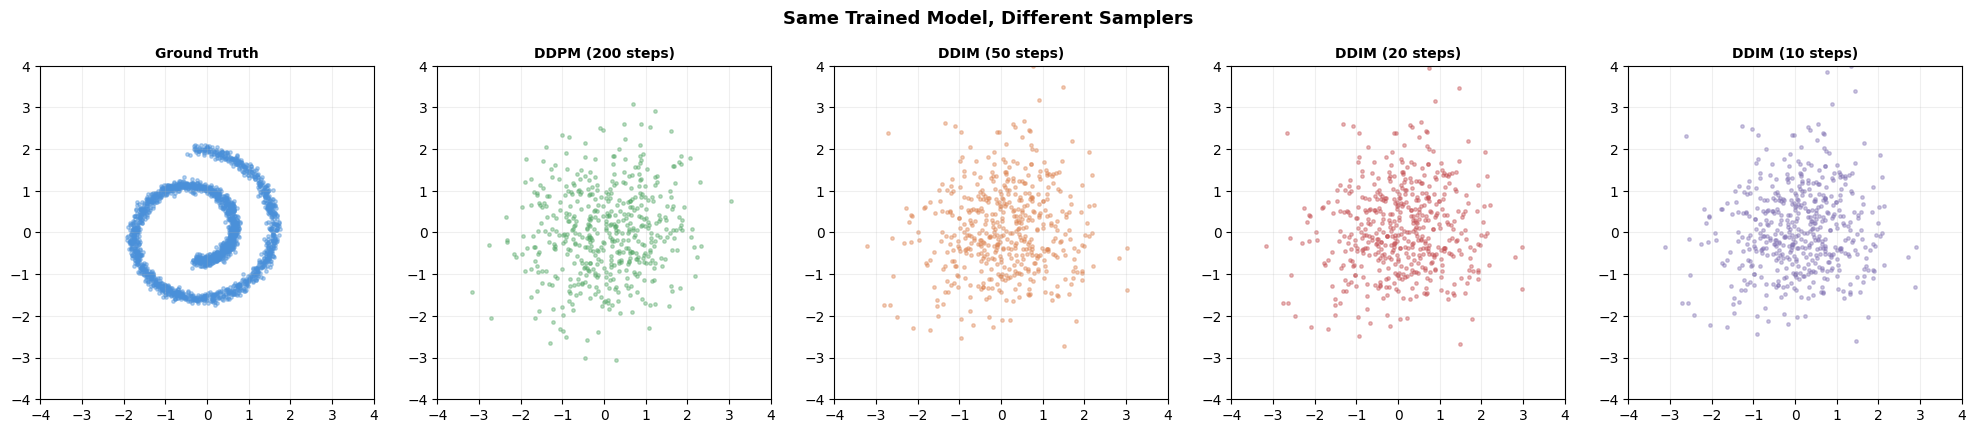

DDIM with 50 steps matches DDPM-200 closely.
At 20 steps the Swiss-roll shape is still clearly captured -- a 10x speedup.
At 10 steps quality starts to degrade, but the overall structure holds.


In [6]:
# --- Visual comparison: DDPM vs DDIM at different step budgets ---
real_data = make_swiss_roll(2000)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

configs = [
    ("Ground Truth", real_data, "#4A90D9"),
    ("DDPM (200 steps)", samples_ddpm, "#55A868"),
    ("DDIM (50 steps)", samples_ddim_50, "#DD8452"),
    ("DDIM (20 steps)", samples_ddim_20, "#C44E52"),
    ("DDIM (10 steps)", samples_ddim_10, "#8172B3"),
]

for ax, (label, samples, color) in zip(axes, configs):
    pts = samples.detach().cpu().numpy() if hasattr(samples, 'detach') else samples.numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.4, c=color)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

fig.suptitle("Same Trained Model, Different Samplers",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print("DDIM with 50 steps matches DDPM-200 closely.")
print("At 20 steps the Swiss-roll shape is still clearly captured -- a 10x speedup.")
print("At 10 steps quality starts to degrade, but the overall structure holds.")

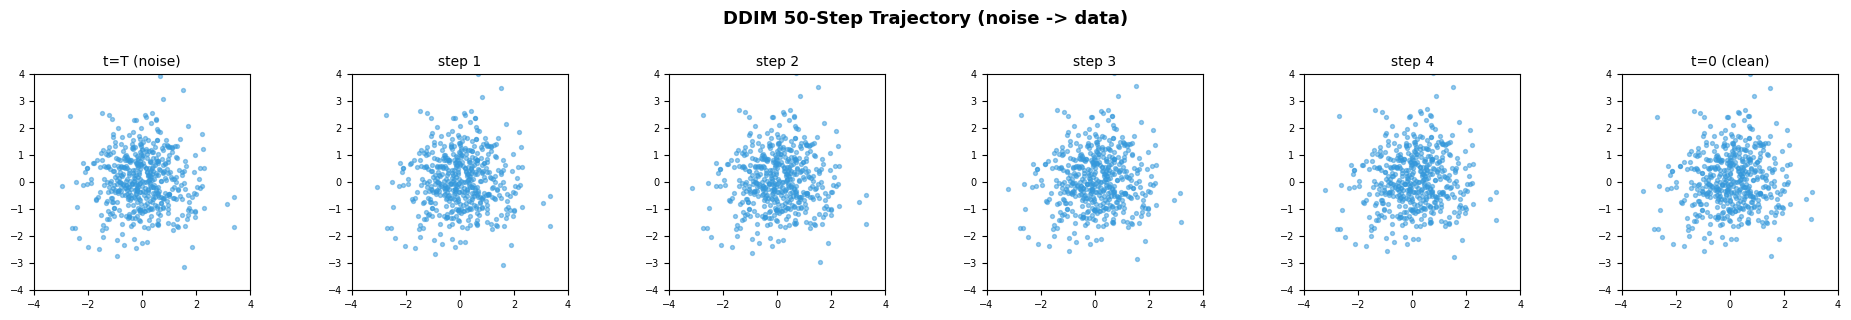

In [7]:
# Visualise a DDIM trajectory (50 steps)
# Pick evenly-spaced snapshots from the trajectory list
n_snaps = min(6, len(traj_ddim_50))
indices = np.linspace(0, len(traj_ddim_50) - 1, n_snaps, dtype=int)
selected = [traj_ddim_50[i] for i in indices]

fig, axes = draw_denoising_trajectory(
    selected, title="DDIM 50-Step Trajectory (noise -> data)"
)
plt.show()

In [8]:
info_box(
    "DDIM 使用的是和 DDPM <b>完全相同的训练好的模型</b>——完全不需要重新训练。"
    "你只需要换一个采样算法就行。这就是 DDIM 影响深远的原因："
    "每个现有的 DDPM 模型检查点立刻就能免费获得 10-20 倍的加速。",
    title="无需重新训练"
)

---
## 3. DPM-Solver：ODE 视角

当 $\eta = 0$ 时，DDIM 揭示了一个深层联系：确定性扩散采样本质上就是在
**求解一个 ODE**（常微分方程）。

### 什么是 ODE？

ODE 描述一个量如何连续变化。扩散模型的**概率流 ODE** 为：

$$\frac{dx}{dt} = f(x, t) - \frac{1}{2}g(t)^2 \nabla_x \log p_t(x)$$

训练好的模型给出了 $\nabla_x \log p_t(x)$（**「得分函数」（Score Function）**，
即对数密度的梯度）。所以采样 = 从 $t = T$（噪声）到 $t = 0$（数据）求解这个 ODE。

### 这有什么帮助？

ODE 求解器已经被研究了几百年。DDIM 等价于**欧拉法**——最简单的一阶求解器。
但更高阶的方法也存在：

| 求解器 | 阶数 | 类比 | 达到好质量所需步数 |
|--------|-------|---------|------------------------|
| DDIM | 一阶 | 欧拉法 | 50+ |
| DPM-Solver-2 | 二阶 | 中点法 | 20-25 |
| DPM-Solver++ | 二至三阶 | 多步法 | 10-20 |

更高阶的求解器每次函数求值（即每次神经网络调用）能获得更高的精度。

In [9]:
# --- Demonstrate Euler vs higher-order solvers on a simple ODE ---
# dy/dt = -y,  exact solution: y(t) = e^{-t}

def euler_solve(f, y0, t_span, n_steps):
    """Euler method (1st order) -- same idea as DDIM."""
    t_start, t_end = t_span
    dt = (t_end - t_start) / n_steps
    t, y = t_start, y0
    traj = [(t, y)]
    for _ in range(n_steps):
        y = y + dt * f(y, t)
        t = t + dt
        traj.append((t, y))
    return traj

def midpoint_solve(f, y0, t_span, n_steps):
    """Midpoint method (2nd order) -- analogous to DPM-Solver-2."""
    t_start, t_end = t_span
    dt = (t_end - t_start) / n_steps
    t, y = t_start, y0
    traj = [(t, y)]
    for _ in range(n_steps):
        k1 = f(y, t)
        k2 = f(y + 0.5 * dt * k1, t + 0.5 * dt)
        y = y + dt * k2
        t = t + dt
        traj.append((t, y))
    return traj

def rk4_solve(f, y0, t_span, n_steps):
    """Classical Runge-Kutta (4th order)."""
    t_start, t_end = t_span
    dt = (t_end - t_start) / n_steps
    t, y = t_start, y0
    traj = [(t, y)]
    for _ in range(n_steps):
        k1 = f(y, t)
        k2 = f(y + 0.5*dt*k1, t + 0.5*dt)
        k3 = f(y + 0.5*dt*k2, t + 0.5*dt)
        k4 = f(y + dt*k3, t + dt)
        y = y + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
        t = t + dt
        traj.append((t, y))
    return traj

ode_f = lambda y, t: -y  # dy/dt = -y
t_exact = np.linspace(0, 3, 200)
y_exact = np.exp(-t_exact)

print("ODE:  dy/dt = -y    (exact solution: y = exp(-t))")
print("Euler (1st order)     ~ DDIM")
print("Midpoint (2nd order)  ~ DPM-Solver-2")
print("RK4 (4th order)       ~ DPM-Solver++ higher order")

ODE:  dy/dt = -y    (exact solution: y = exp(-t))
Euler (1st order)     ~ DDIM
Midpoint (2nd order)  ~ DPM-Solver-2
RK4 (4th order)       ~ DPM-Solver++ higher order


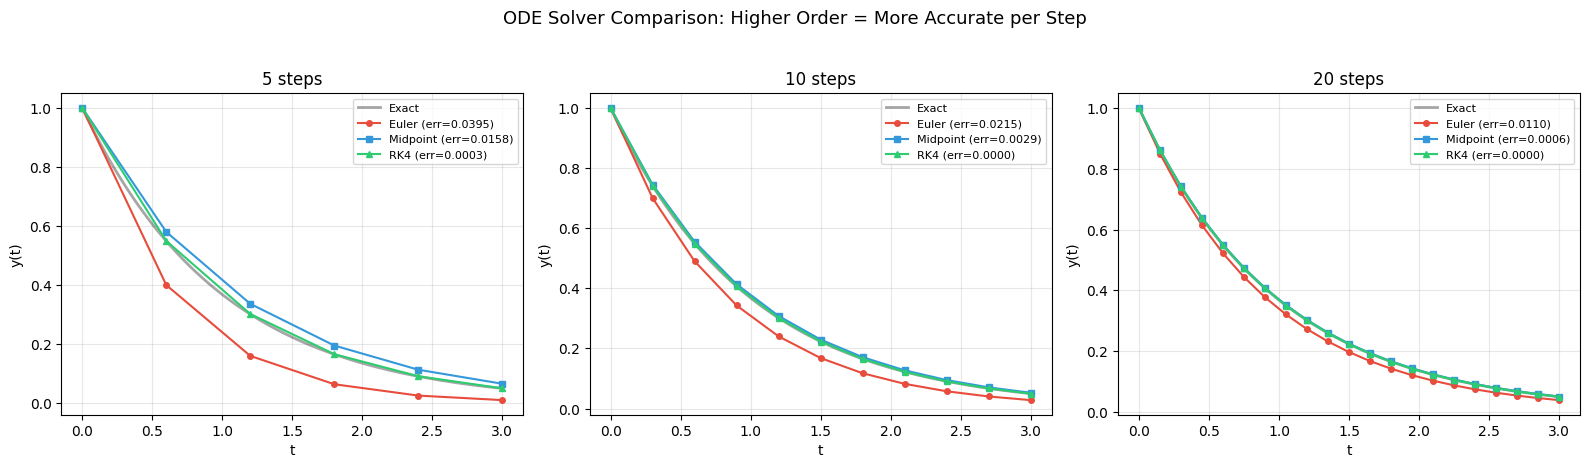

With only 5 steps, Euler has large error but Midpoint is already close.
This is exactly why DPM-Solver-2 beats DDIM at low step counts.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, n_steps in zip(axes, [5, 10, 20]):
    traj_e = euler_solve(ode_f, 1.0, (0, 3), n_steps)
    traj_m = midpoint_solve(ode_f, 1.0, (0, 3), n_steps)
    traj_r = rk4_solve(ode_f, 1.0, (0, 3), n_steps)

    ax.plot(t_exact, y_exact, 'k-', linewidth=2, label='Exact', alpha=0.35)

    ts, ys = zip(*traj_e)
    ax.plot(ts, ys, 'o-', color='#e74c3c', markersize=4, linewidth=1.5,
            label=f'Euler (err={abs(ys[-1]-np.exp(-3)):.4f})')
    ts, ys = zip(*traj_m)
    ax.plot(ts, ys, 's-', color='#3498db', markersize=4, linewidth=1.5,
            label=f'Midpoint (err={abs(ys[-1]-np.exp(-3)):.4f})')
    ts, ys = zip(*traj_r)
    ax.plot(ts, ys, '^-', color='#2ecc71', markersize=4, linewidth=1.5,
            label=f'RK4 (err={abs(ys[-1]-np.exp(-3)):.4f})')

    ax.set_title(f'{n_steps} steps', fontsize=12)
    ax.set_xlabel('t'); ax.set_ylabel('y(t)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('ODE Solver Comparison: Higher Order = More Accurate per Step',
             fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

print("With only 5 steps, Euler has large error but Midpoint is already close.")
print("This is exactly why DPM-Solver-2 beats DDIM at low step counts.")

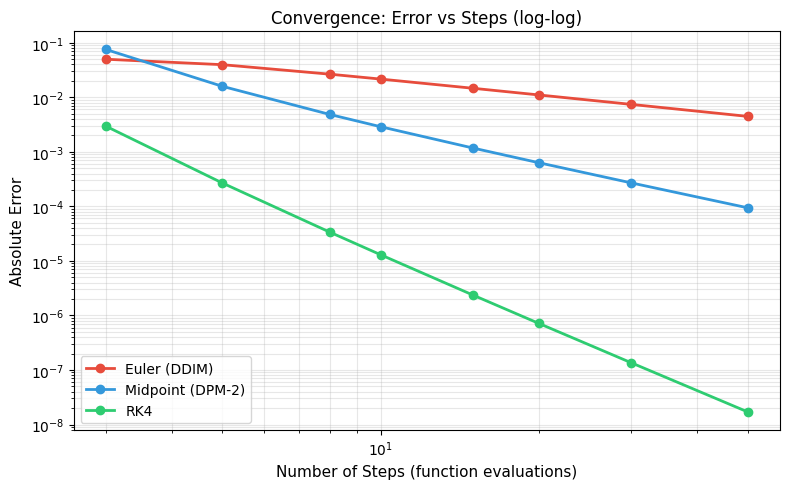

Steeper slope = faster convergence:
  Euler (order 1): error ~ 1/N
  Midpoint (order 2): error ~ 1/N^2
  RK4 (order 4): error ~ 1/N^4


In [11]:
# --- Convergence plot: error vs number of steps ---
step_counts = [3, 5, 8, 10, 15, 20, 30, 50]
errors = {'Euler (DDIM)': [], 'Midpoint (DPM-2)': [], 'RK4': []}

for n in step_counts:
    exact_val = np.exp(-3)
    errors['Euler (DDIM)'].append(abs(euler_solve(ode_f, 1.0, (0,3), n)[-1][1] - exact_val))
    errors['Midpoint (DPM-2)'].append(abs(midpoint_solve(ode_f, 1.0, (0,3), n)[-1][1] - exact_val))
    errors['RK4'].append(abs(rk4_solve(ode_f, 1.0, (0,3), n)[-1][1] - exact_val))

fig, ax = plt.subplots(figsize=(8, 5))
for name, color in [('Euler (DDIM)', '#e74c3c'),
                     ('Midpoint (DPM-2)', '#3498db'),
                     ('RK4', '#2ecc71')]:
    ax.loglog(step_counts, errors[name], 'o-', color=color, linewidth=2,
              markersize=6, label=name)

ax.set_xlabel('Number of Steps (function evaluations)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('Convergence: Error vs Steps (log-log)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
fig.tight_layout()
plt.show()

print("Steeper slope = faster convergence:")
print("  Euler (order 1): error ~ 1/N")
print("  Midpoint (order 2): error ~ 1/N^2")
print("  RK4 (order 4): error ~ 1/N^4")

In [12]:
info_box(
    "<b>DPM-Solver-2</b> 通常在 <b>20-25 步</b>就能给出不错的结果。"
    "<b>DPM-Solver++</b>（Lu et al., 2022）通过在数据预测空间中工作并使用多步方法进一步改进，"
    "最少只需 <b>10-15 步</b>就能达到不错的质量。大多数生产系统（Stable Diffusion、"
    "Midjourney）都使用 DPM-Solver++ 作为默认采样器。",
    title="DPM-Solver 的实际应用"
)

---
## 4. 渐进蒸馏：教学生迈更大的步子

DDIM 和 DPM-Solver 是**无需训练的**——它们通过更聪明的 ODE 求解器来加速现有模型。
但当步数低于约 10 步时，质量会明显下降，因为 ODE 近似累积了太多误差。

**「渐进蒸馏」（Progressive Distillation）**（Salimans & Ho, 2022）突破了这个下限，
方法是训练一个新模型。

### 它是怎么工作的

1. 从一个能在 $N$ 步内良好采样的**教师**模型开始（如 1024 步）
2. 训练一个**学生**，让它用 1 步做到教师用 2 步才能做到的事
3. 现在学生只需 $N/2$ 步就能匹配教师的质量
4. 学生变成新的教师；重复
5. 每轮步数减半：1024 -> 512 -> 256 -> ... -> 4 -> 2 -> 1

### 为什么不直接训练一个 1 步模型？

一步就把纯噪声映射到数据是一个极其复杂的函数。
渐进蒸馏通过将其分解为小的、可学习的增量来使之可行。
每个学生只需要学会比其教师*稍微大一点*的跳跃——这是一个容易得多的回归问题。

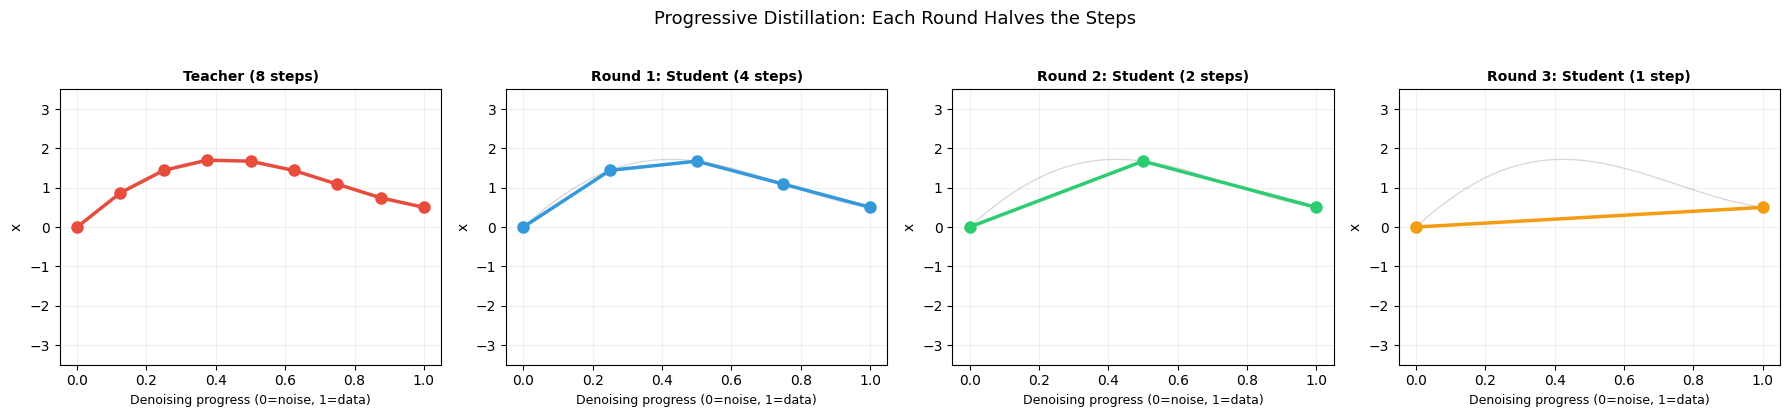

Each student learns to 'shortcut' through the teacher's trajectory.
Round 1: 8->4 steps | Round 2: 4->2 steps | Round 3: 2->1 step


In [13]:
# --- Visualise the progressive distillation concept ---
torch.manual_seed(42)

# Simulate a "denoising trajectory" as a sequence of points in 1D
teacher_steps = 8
t_teacher = torch.linspace(0, 1, teacher_steps + 1)
x_teacher = 3.0 * torch.sin(2.5 * t_teacher) * (1 - t_teacher) + 0.5 * t_teacher

# Each distillation round takes every other point
student1_idx = list(range(0, teacher_steps + 1, 2))  # 4 steps
student2_idx = list(range(0, teacher_steps + 1, 4))  # 2 steps
student3_idx = [0, teacher_steps]                     # 1 step

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Smooth background curve for reference
t_smooth = torch.linspace(0, 1, 200)
x_smooth = 3.0 * torch.sin(2.5 * t_smooth) * (1 - t_smooth) + 0.5 * t_smooth

configs = [
    ("Teacher (8 steps)", t_teacher, x_teacher, '#e74c3c'),
    ("Round 1: Student (4 steps)", t_teacher[student1_idx], x_teacher[student1_idx], '#3498db'),
    ("Round 2: Student (2 steps)", t_teacher[student2_idx], x_teacher[student2_idx], '#2ecc71'),
    ("Round 3: Student (1 step)", t_teacher[student3_idx], x_teacher[student3_idx], '#f39c12'),
]

for ax, (label, ts, xs, color) in zip(axes, configs):
    ax.plot(t_smooth.numpy(), x_smooth.numpy(), 'k-', alpha=0.15, linewidth=1)
    ax.plot(ts.numpy(), xs.numpy(), 'o-', color=color, markersize=8,
            linewidth=2.5, zorder=5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Denoising progress (0=noise, 1=data)', fontsize=9)
    ax.set_ylabel('x', fontsize=10)
    ax.grid(alpha=0.2)
    ax.set_ylim(-3.5, 3.5)

fig.suptitle('Progressive Distillation: Each Round Halves the Steps',
             fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

print("Each student learns to 'shortcut' through the teacher's trajectory.")
print("Round 1: 8->4 steps | Round 2: 4->2 steps | Round 3: 2->1 step")

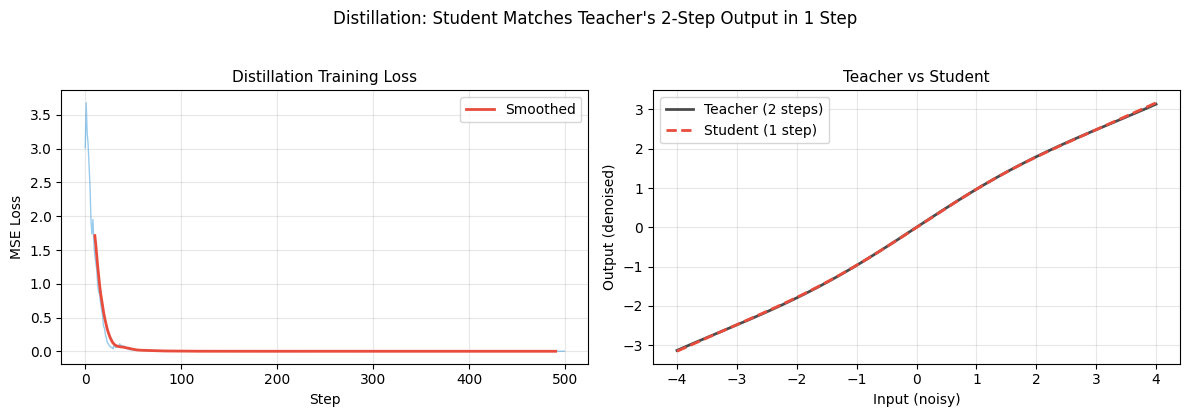

Final distillation loss: 0.000800


In [14]:
# --- Toy distillation demo: student learns teacher's 2-step output in 1 step ---
torch.manual_seed(42)

def teacher_2step(x):
    """Simulate a teacher taking 2 nonlinear denoising steps."""
    x_mid = x * 0.9 + 0.1 * torch.sin(x)
    return x_mid * 0.9 + 0.1 * torch.sin(x_mid)

student = nn.Sequential(
    nn.Linear(1, 64), nn.SiLU(),
    nn.Linear(64, 64), nn.SiLU(),
    nn.Linear(64, 1),
)
optimizer = torch.optim.Adam(student.parameters(), lr=1e-3)

distill_losses = []
for step in range(500):
    x_noisy = torch.randn(256, 1) * 2
    with torch.no_grad():
        target = teacher_2step(x_noisy)
    pred = student(x_noisy)
    loss = F.mse_loss(pred, target)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    distill_losses.append(loss.item())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(distill_losses, color='#3498db', linewidth=1, alpha=0.5)
w = 20
sm = np.convolve(distill_losses, np.ones(w)/w, mode='valid')
axes[0].plot(range(w//2, w//2+len(sm)), sm, color='#e74c3c', linewidth=2, label='Smoothed')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Distillation Training Loss', fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3)

x_test = torch.linspace(-4, 4, 200).unsqueeze(1)
with torch.no_grad():
    y_t = teacher_2step(x_test)
    y_s = student(x_test)
axes[1].plot(x_test.numpy(), y_t.numpy(), 'k-', linewidth=2, label='Teacher (2 steps)', alpha=0.7)
axes[1].plot(x_test.numpy(), y_s.numpy(), '--', color='#e74c3c', linewidth=2, label='Student (1 step)')
axes[1].set_xlabel('Input (noisy)'); axes[1].set_ylabel('Output (denoised)')
axes[1].set_title('Teacher vs Student', fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle('Distillation: Student Matches Teacher\'s 2-Step Output in 1 Step',
             fontsize=12, y=1.03)
fig.tight_layout()
plt.show()

print(f"Final distillation loss: {distill_losses[-1]:.6f}")

In [15]:
info_box(
    "渐进蒸馏是让 <b>Stable Diffusion</b> 在仅 <b>4 步</b>内运行的关键技术，"
    "使实时应用成为可能。该技术驱动了 <b>SDXL Turbo</b> 和 <b>LCM（Latent Consistency Models）</b>。"
    "代价是：蒸馏需要额外的训练阶段，而且学生可能会比全步教师丢失一些细节。",
    title="渐进蒸馏的实际应用"
)

---
## 5. 一致性模型：一步生成

**「一致性模型」（Consistency Models）**（Song et al., 2023）采取了最激进的策略：
将任意带噪的 $x_t$ 在**一步之内**直接映射到 $x_0$。

### 核心思想：自一致性

考虑连接噪声 $x_T$ 和干净数据 $x_0$ 的 ODE 轨迹。
这条轨迹上的每个点最终都到达同一个 $x_0$。
一致性模型 $f_\theta$ 强制满足这一性质：

$$f_\theta(x_t, t) = f_\theta(x_s, s) \quad \text{对同一轨迹上的所有 } s, t \text{ 成立}$$

这就是**自一致性**。如果模型满足这个性质，
我们就可以从任意噪声水平一步直接跳到 $x_0$。

### 边界条件

在 $t \approx 0$（近乎干净的数据）时，模型必须原样返回输入：
$f_\theta(x_0, 0) = x_0$。这锚定了一致性约束。

### 两种训练方式

1. **一致性蒸馏**——利用预训练的扩散模型生成轨迹点对，
   然后训练 $f_\theta$ 将两者映射到相同的输出
2. **一致性训练**——直接使用自一致性损失从零训练，
   不需要教师模型

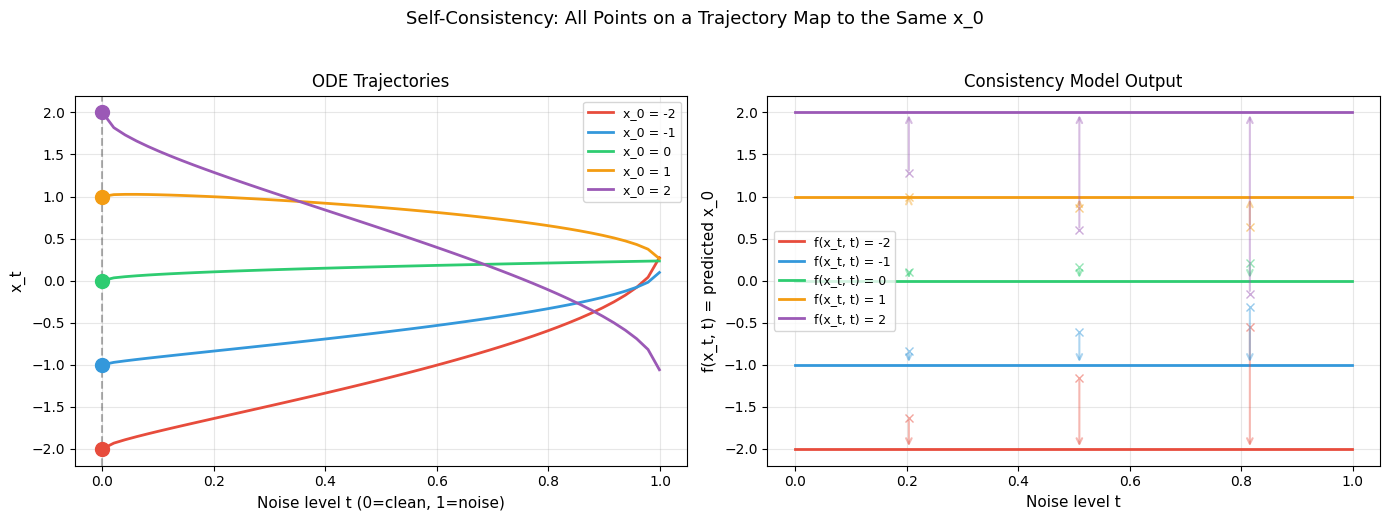

Left: each trajectory goes from clean x_0 (t=0) into noise (t~1).
Right: the consistency model outputs the SAME x_0 regardless of the
noise level t. This is what enables one-step generation.


In [16]:
# --- Visualise the self-consistency property ---
torch.manual_seed(42)

n_traj = 5
x0_vals = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
eps_vals = torch.randn(n_traj)
t_vals = torch.linspace(0, 0.999, 50)
ab_viz = 1.0 - t_vals  # simplified linear alpha_bar

colors_traj = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ODE trajectories
ax = axes[0]
for i in range(n_traj):
    x_t = torch.sqrt(ab_viz) * x0_vals[i] + torch.sqrt(1 - ab_viz) * eps_vals[i]
    ax.plot(t_vals.numpy(), x_t.numpy(), '-', color=colors_traj[i], linewidth=2,
            label=f'x_0 = {x0_vals[i]:.0f}')
    ax.plot(0, x0_vals[i].item(), 'o', color=colors_traj[i], markersize=10, zorder=5)
ax.set_xlabel('Noise level t (0=clean, 1=noise)', fontsize=11)
ax.set_ylabel('x_t', fontsize=11)
ax.set_title('ODE Trajectories', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

# Right: consistency model output (constant along each trajectory)
ax = axes[1]
for i in range(n_traj):
    x_t = torch.sqrt(ab_viz) * x0_vals[i] + torch.sqrt(1 - ab_viz) * eps_vals[i]
    # A perfect consistency model maps every point to x_0
    ax.plot(t_vals.numpy(), torch.full_like(t_vals, x0_vals[i]).numpy(),
            '-', color=colors_traj[i], linewidth=2,
            label=f'f(x_t, t) = {x0_vals[i]:.0f}')
    # Arrows from trajectory points to x_0
    for t_idx in [10, 25, 40]:
        ax.annotate('', xy=(t_vals[t_idx], x0_vals[i]),
                    xytext=(t_vals[t_idx], x_t[t_idx]),
                    arrowprops=dict(arrowstyle='->', color=colors_traj[i],
                                   alpha=0.4, lw=1.5))
        ax.plot(t_vals[t_idx], x_t[t_idx], 'x', color=colors_traj[i],
                markersize=6, alpha=0.5)
ax.set_xlabel('Noise level t', fontsize=11)
ax.set_ylabel('f(x_t, t) = predicted x_0', fontsize=11)
ax.set_title('Consistency Model Output', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Self-Consistency: All Points on a Trajectory Map to the Same x_0',
             fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

print("Left: each trajectory goes from clean x_0 (t=0) into noise (t~1).")
print("Right: the consistency model outputs the SAME x_0 regardless of the")
print("noise level t. This is what enables one-step generation.")

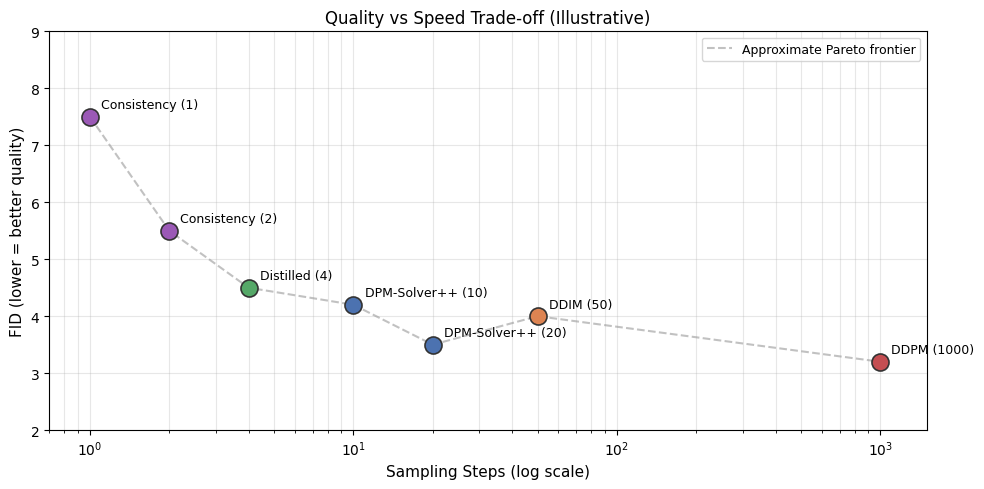

Note: FID values are illustrative, not from a specific benchmark.
The general trend is consistent across published results.


In [17]:
# --- Quality vs speed: the fundamental trade-off ---
methods = [
    ('DDPM (1000)',      1000, 3.2, '#C44E52'),
    ('DDIM (50)',          50, 4.0, '#DD8452'),
    ('DPM-Solver++ (20)',  20, 3.5, '#4C72B0'),
    ('DPM-Solver++ (10)',  10, 4.2, '#4C72B0'),
    ('Distilled (4)',       4, 4.5, '#55A868'),
    ('Consistency (2)',     2, 5.5, '#9b59b6'),
    ('Consistency (1)',     1, 7.5, '#9b59b6'),
]

fig, ax = plt.subplots(figsize=(10, 5))
for name, steps, fid, color in methods:
    ax.scatter(steps, fid, s=150, c=color, edgecolors='#333',
              linewidths=1.2, zorder=3)
    ax.annotate(name, (steps, fid), textcoords='offset points',
                xytext=(8, 6), fontsize=9)

pareto_x = [1, 2, 4, 10, 20, 50, 1000]
pareto_y = [7.5, 5.5, 4.5, 4.2, 3.5, 4.0, 3.2]
ax.plot(pareto_x, pareto_y, '--', color='#999', linewidth=1.5, alpha=0.6,
        label='Approximate Pareto frontier')

ax.set_xscale('log')
ax.set_xlabel('Sampling Steps (log scale)', fontsize=11)
ax.set_ylabel('FID (lower = better quality)', fontsize=11)
ax.set_title('Quality vs Speed Trade-off (Illustrative)', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
ax.set_xlim(0.7, 1500); ax.set_ylim(2, 9)
fig.tight_layout()
plt.show()

print("Note: FID values are illustrative, not from a specific benchmark.")
print("The general trend is consistent across published results.")

---
## 6. 生产环境采样器选择指南

这么多选择，到底该用哪个采样器？

In [18]:
info_box(
    '<table style="width:100%; border-collapse:collapse; font-size:13px;">'
    '<tr style="border-bottom:2px solid #4A90D9;">'
    '<th style="text-align:left;padding:6px;">采样器</th>'
    '<th style="text-align:center;padding:6px;">步数</th>'
    '<th style="text-align:center;padding:6px;">质量</th>'
    '<th style="text-align:center;padding:6px;">速度</th>'
    '<th style="text-align:left;padding:6px;">使用场景</th>'
    '<th style="text-align:center;padding:6px;">需要重训？</th></tr>'
    '<tr style="border-bottom:1px solid #ddd;">'
    '<td style="padding:6px;"><b>DDPM</b></td>'
    '<td style="text-align:center;">1000</td>'
    '<td style="text-align:center;">最佳</td>'
    '<td style="text-align:center;">慢</td>'
    '<td style="padding:6px;">研究基准</td>'
    '<td style="text-align:center;">否</td></tr>'
    '<tr style="border-bottom:1px solid #ddd;">'
    '<td style="padding:6px;"><b>DDIM</b></td>'
    '<td style="text-align:center;">50</td>'
    '<td style="text-align:center;">好</td>'
    '<td style="text-align:center;">中等</td>'
    '<td style="padding:6px;">通用、插值</td>'
    '<td style="text-align:center;">否</td></tr>'
    '<tr style="border-bottom:1px solid #ddd;">'
    '<td style="padding:6px;"><b>DPM-Solver++</b></td>'
    '<td style="text-align:center;">20</td>'
    '<td style="text-align:center;">好</td>'
    '<td style="text-align:center;">快</td>'
    '<td style="padding:6px;">生产默认</td>'
    '<td style="text-align:center;">否</td></tr>'
    '<tr style="border-bottom:1px solid #ddd;">'
    '<td style="padding:6px;"><b>蒸馏模型 (LCM)</b></td>'
    '<td style="text-align:center;">4</td>'
    '<td style="text-align:center;">好</td>'
    '<td style="text-align:center;">很快</td>'
    '<td style="padding:6px;">低延迟应用</td>'
    '<td style="text-align:center;">是</td></tr>'
    '<tr>'
    '<td style="padding:6px;"><b>一致性模型</b></td>'
    '<td style="text-align:center;">1-2</td>'
    '<td style="text-align:center;">尚可</td>'
    '<td style="text-align:center;">最快</td>'
    '<td style="padding:6px;">实时、交互式</td>'
    '<td style="text-align:center;">是</td></tr>'
    '</table>',
    title="采样器对比"
)

采样器,步数,质量,速度,使用场景,需要重训？
DDPM,1000,最佳,慢,研究基准,否
DDIM,50,好,中等,通用、插值,否
DPM-Solver++,20,好,快,生产默认,否
蒸馏模型 (LCM),4,好,很快,低延迟应用,是
一致性模型,1-2,尚可,最快,实时、交互式,是


In [19]:
info_box(
    "大多数生产系统默认使用 <b>DPM-Solver++</b>，步数为 <b>20-25 步</b>。"
    "它不需要重新训练，适用于任何 DDPM 训练好的模型检查点，"
    "在质量和速度之间取得了出色的平衡。实时应用可以使用蒸馏模型或一致性模型，只需 1-4 步。",
    title="生产环境推荐"
)

print("关于采样之外的推理加速方法，请参见：")
print("  模型编译：../../en/inference/07-model-compilation.ipynb")
print("  （涵盖 torch.compile、ONNX 导出、TensorRT 优化）")

关于采样之外的推理加速方法，请参见：
  模型编译：../../en/inference/07-model-compilation.ipynb
  （涵盖 torch.compile、ONNX 导出、TensorRT 优化）


---
## 7. 总结与延伸阅读

### 核心要点

- **DDPM 很慢**：每个样本需要 1000 次顺序前向传播
- **DDIM**（无需重训）：确定性地跳过时间步，约 50 步即可达到接近的质量
- **DPM-Solver**（无需重训）：更高阶的 ODE 求解器，约 20 步即可获得好质量
- **渐进蒸馏**（需要训练）：训练学生在每轮将教师的步数减半，最低到 4 步
- **一致性模型**（需要训练）：通过强制自一致性实现一步生成
- **生产甜区**：DPM-Solver++ 20-25 步，或 LCM 4 步用于实时场景

### 论文引用

1. **DDIM**: Song, Meng, Ermon. *Denoising Diffusion Implicit Models* (2020). [arXiv:2010.02502](https://arxiv.org/abs/2010.02502)
2. **DPM-Solver**: Lu et al. *DPM-Solver: A Fast ODE Solver for Diffusion Probabilistic Model Sampling* (2022). [arXiv:2206.00927](https://arxiv.org/abs/2206.00927)
3. **DPM-Solver++**: Lu et al. *DPM-Solver++: Fast Solver for Guided Sampling* (2022). [arXiv:2211.01095](https://arxiv.org/abs/2211.01095)
4. **渐进蒸馏**: Salimans & Ho. *Progressive Distillation for Fast Sampling of Diffusion Models* (2022). [arXiv:2202.00512](https://arxiv.org/abs/2202.00512)
5. **一致性模型**: Song et al. *Consistency Models* (2023). [arXiv:2303.01469](https://arxiv.org/abs/2303.01469)

### 下一个 notebook

[02-classifier-free-guidance.ipynb](02-classifier-free-guidance.ipynb) -- 如何使用单个模型通过文本或类别标签引导生成